# Estimation des Niveaux de Santé par Machine Learning

Ce notebook présente une étude complète sur l'estimation des niveaux d'obésité basée sur les habitudes alimentaires et l'état physique des individus. Les données proviennent du dépôt **UCI Machine Learning Repository**.

## Objectifs :
1. **Analyse Exploratoire (EDA)** : Comprendre les facteurs influençant le poids.
2. **Prétraitement** : Nettoyer et transformer les données pour le Machine Learning.
3. **Modélisation** : Comparer les performances de **Random Forest** et **XGBoost**.
4. **Démonstration** : Utiliser le modèle pour des prédictions en temps réel.

## 1. Importation des bibliothèques et Chargement des données

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os

# Chargement du dataset
df = pd.read_csv('data/obesity_data.csv')
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 2. Analyse Exploratoire des Données (EDA)

Nous examinons la distribution de notre variable cible `NObeyesdad` et la corrélation entre les variables numériques.

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7476\2622339190.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='NObeyesdad', order=df['NObeyesdad'].value_counts().index, palette='viridis')


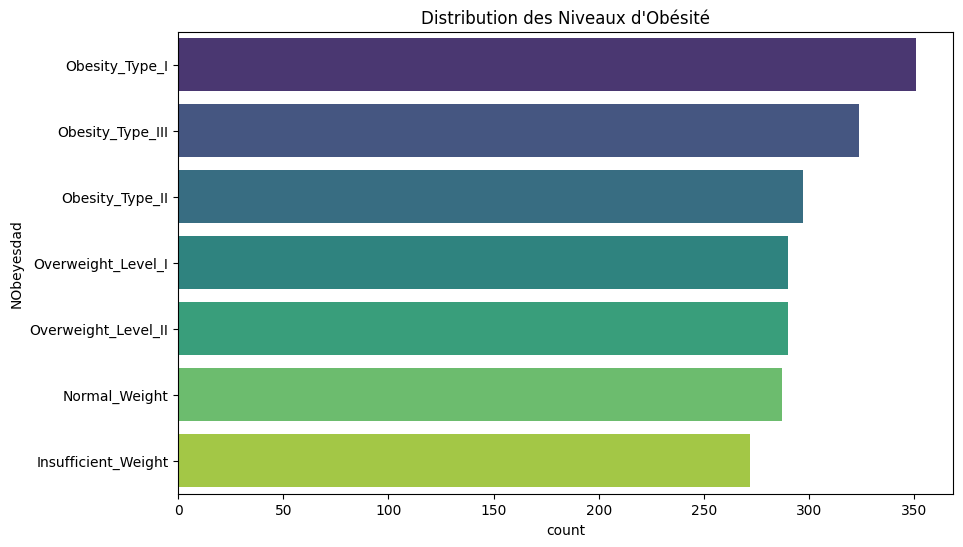

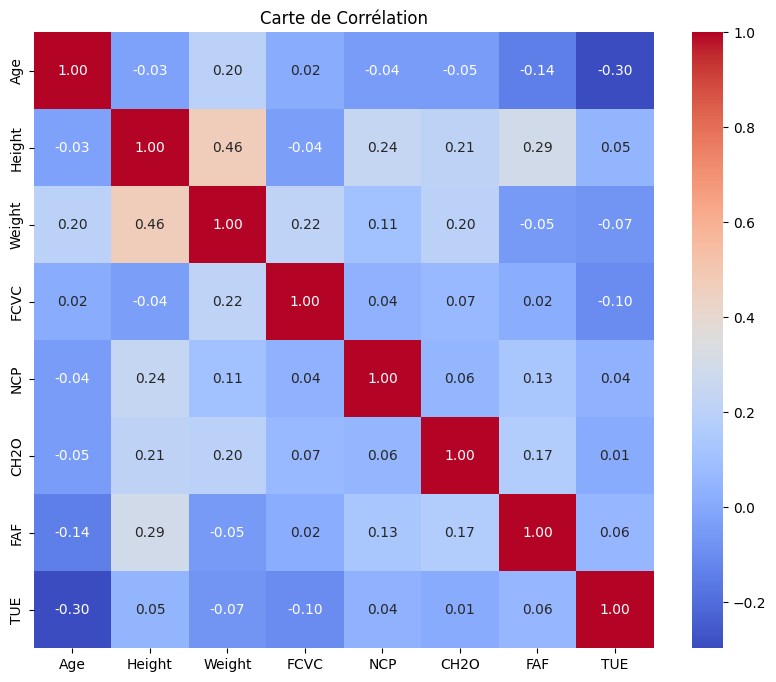

In [8]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='NObeyesdad', order=df['NObeyesdad'].value_counts().index, palette='viridis', hue='NObeyesdad', legend=False)
plt.title('Distribution des Niveaux d\'Obésité')
plt.show()

# Corrélation entre variables numériques
numeric_df = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Carte de Corrélation')
plt.show()

## 3. Évaluation des Modèles

Nous avons entraîné deux modèles : **Random Forest** et **XGBoost**. Voici les résultats comparés.

In [9]:
import json

with open('results/metrics.json', 'r') as f:
    metrics = json.load(f)

comparison = pd.DataFrame({
    'Random Forest': metrics['Random Forest'],
    'XGBoost': metrics['XGBoost']
}).drop('report')

display(comparison.T)

,f1_macro,precision_macro,recall_macro
Random Forest,0.941226,0.946391,0.93949
XGBoost,0.951706,0.953916,0.951201


### Matrice de Confusion (XGBoost)
XGBoost a montré les meilleures performances. Voyons précisément où le modèle fait des erreurs via la matrice de confusion.

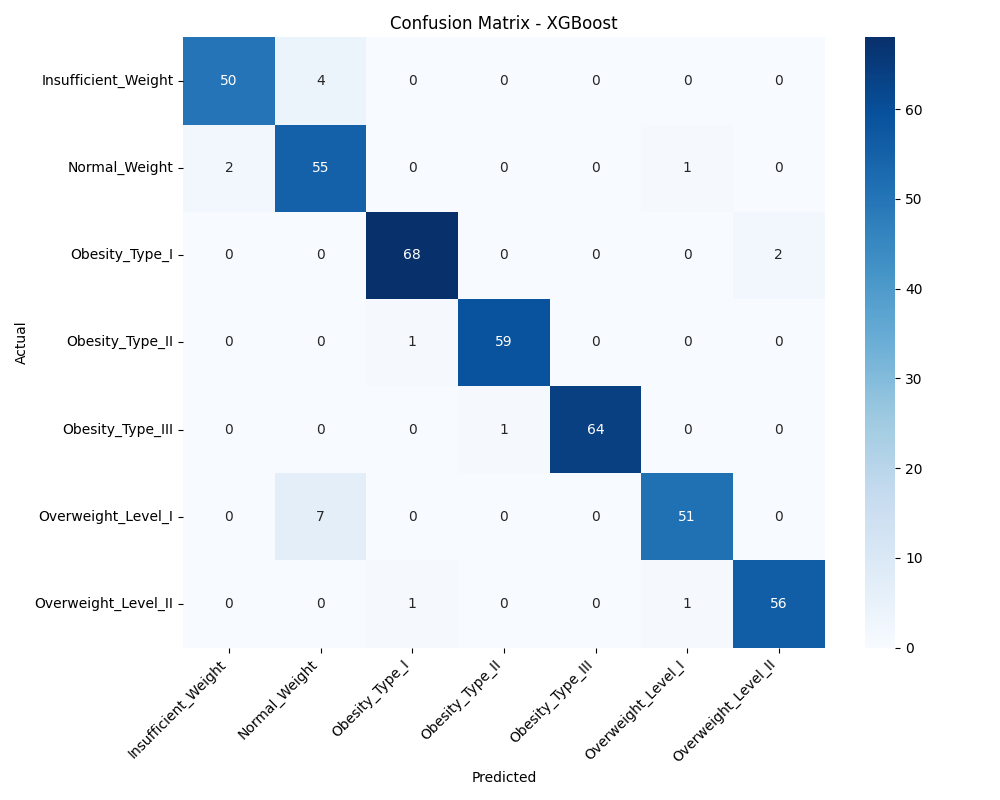

In [10]:
from IPython.display import Image
Image(filename='plots/cm_xgboost.png')

## 4. Démonstration : Prédiction Interactive

Ici, nous chargeons le préprocesseur et le modèle final pour estimer le niveau de santé d'un nouvel individu.

In [11]:
def predict_health_level(input_data):
    """
    input_data: Dictionnaire contenant les features brutes
    """
    # Chargement des outils
    preprocessor = joblib.load('models/preprocessor.pkl')
    model = joblib.load('models/xgboost_model.pkl')
    target_encoder = joblib.load('models/target_encoder.pkl')
    
    # Conversion en DataFrame
    new_df = pd.DataFrame([input_data])
    
    # Prétraitement
    processed_data = preprocessor.transform(new_df)
    
    # Prédiction
    prediction_idx = model.predict(processed_data)[0]
    prediction_label = target_encoder.inverse_transform([prediction_idx])[0]
    
    return prediction_label

# EXEMPLE DE TEST
example_person = {
    'Gender': 'Female', 
    'Age': 21.0, 
    'Height': 1.62, 
    'Weight': 64.0, 
    'family_history_with_overweight': 'yes', 
    'FAVC': 'no', 
    'FCVC': 2.0, 
    'NCP': 3.0, 
    'CAEC': 'Sometimes', 
    'SMOKE': 'no', 
    'CH2O': 2.0, 
    'SCC': 'no', 
    'FAF': 0.0, 
    'TUE': 1.0, 
    'CALC': 'no', 
    'MTRANS': 'Public_Transportation'
}

res = predict_health_level(example_person)
print(f"Le niveau de santé estimé est : {res}")

Le niveau de santé estimé est : Normal_Weight


### Importance des variables
Enfin, visualisons quels facteurs ont le plus influencé le modèle.

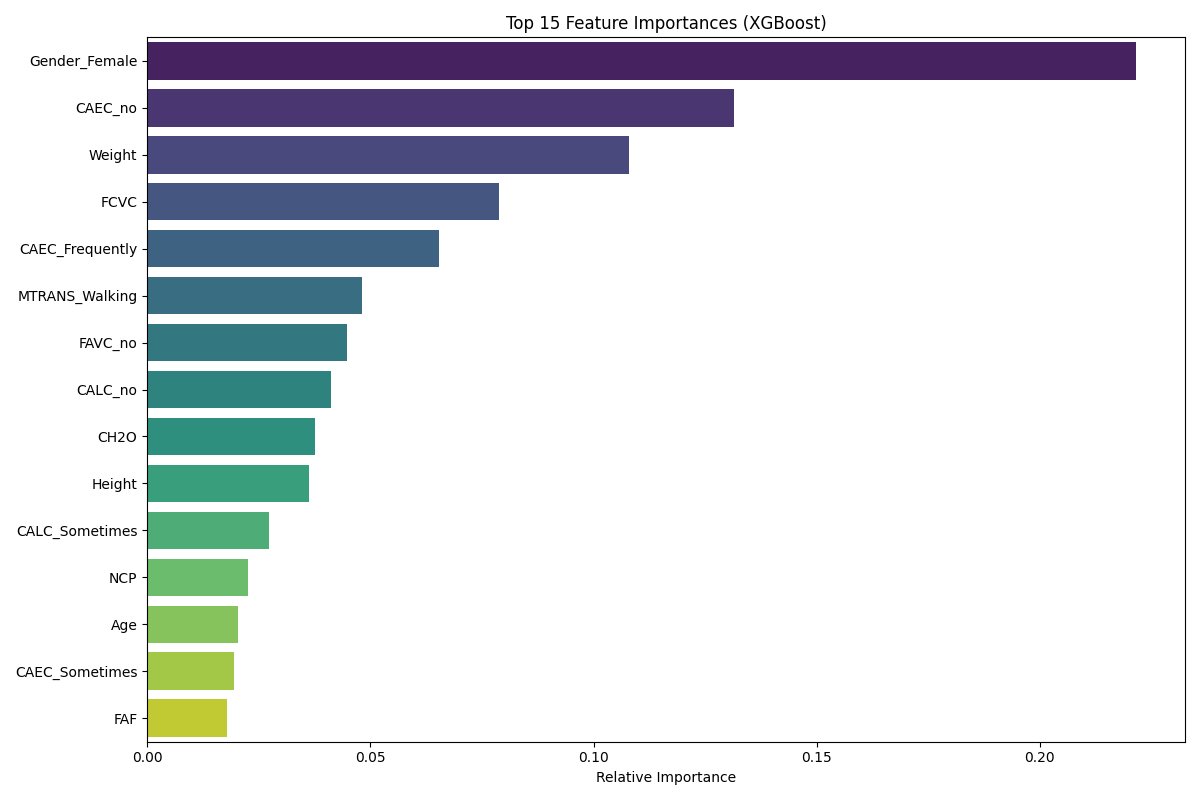

In [12]:
Image(filename='plots/feature_importance.png')